In [7]:
# =========================
# 1. INSTALL + IMPORTS
# =========================
!pip install -q kaggle opencv-python tensorflow

import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

IMG_SIZE = 64
BATCH_SIZE = 8
EPOCHS = 10
DATA_PATH = "/content/dataset"

# =========================
# 2. LOAD DATA
# =========================
def load_images(path):
    images = []
    for root, _, files in os.walk(path):
        for file in files:
            if file.endswith(('.png', '.jpg', '.jpeg')):
                img = cv2.imread(os.path.join(root, file))
                if img is None:
                    continue
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0
                images.append(img)
    return np.array(images)

def create_lr_hr(images):
    lr = []
    hr = images
    for img in images:
        small = cv2.resize(img, (IMG_SIZE//2, IMG_SIZE//2))
        up = cv2.resize(small, (IMG_SIZE, IMG_SIZE))
        lr.append(up)
    return np.array(lr), np.array(hr)

images = load_images(DATA_PATH)
lr_images, hr_images = create_lr_hr(images)



In [8]:
# =========================
# 3. BASELINE GAN (SR)
# =========================
def build_generator():
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(inp)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    out = layers.Conv2D(3, 3, padding='same', activation='sigmoid')(x)
    return Model(inp, out)

def build_discriminator():
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(64, 3, strides=2, padding='same')(inp)
    x = layers.LeakyReLU()(x)
    x = layers.Flatten()(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return Model(inp, out)

gen = build_generator()
disc = build_discriminator()
disc.compile(optimizer='adam', loss='binary_crossentropy')

disc.trainable = False
inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
fake = gen(inp)
valid = disc(fake)
gan = Model(inp, valid)
gan.compile(optimizer='adam', loss='binary_crossentropy')

# =========================
# 4. TRAIN GAN
# =========================
for epoch in range(EPOCHS):
    for i in range(len(hr_images)//BATCH_SIZE):
        hr = hr_images[i*BATCH_SIZE:(i+1)*BATCH_SIZE]
        lr = lr_images[i*BATCH_SIZE:(i+1)*BATCH_SIZE]

        fake = gen.predict(lr, verbose=0)

        real_label = np.ones((BATCH_SIZE,1))
        fake_label = np.zeros((BATCH_SIZE,1))

        d_loss_real = disc.train_on_batch(hr, real_label)
        d_loss_fake = disc.train_on_batch(fake, fake_label)

        g_loss = gan.train_on_batch(lr, real_label)

    print(f"GAN Epoch {epoch+1}: D={d_loss_real+d_loss_fake:.4f}, G={g_loss:.4f}")




GAN Epoch 1: D=1.5663, G=0.5596
GAN Epoch 2: D=1.5747, G=0.5532
GAN Epoch 3: D=1.5777, G=0.5509
GAN Epoch 4: D=1.5796, G=0.5495
GAN Epoch 5: D=1.5809, G=0.5485
GAN Epoch 6: D=1.5824, G=0.5474
GAN Epoch 7: D=1.5872, G=0.5439
GAN Epoch 8: D=1.5927, G=0.5401
GAN Epoch 9: D=1.5972, G=0.5370
GAN Epoch 10: D=1.6013, G=0.5342


In [10]:
# =========================
# 5. SRGAN (WITH PERCEPTUAL LOSS)
# =========================
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
vgg.trainable = False
feature_extractor = Model(vgg.input, vgg.layers[5].output)

def residual_block(x):
    res = layers.Conv2D(64, 3, padding='same')(x)
    res = layers.BatchNormalization()(res)
    res = layers.ReLU()(res)
    res = layers.Conv2D(64, 3, padding='same')(res)
    res = layers.BatchNormalization()(res)
    return layers.Add()([x, res])

def srgan_generator():
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(64, 9, padding='same')(inp)
    x = layers.ReLU()(x)
    for _ in range(5):
        x = residual_block(x)
    out = layers.Conv2D(3, 3, padding='same', activation='sigmoid')(x)
    return Model(inp, out)

gen_sr = srgan_generator()
disc_sr = build_discriminator()
disc_sr.compile(optimizer='adam', loss='binary_crossentropy')

# Create a combined SRGAN model for generator training
# Make discriminator non-trainable when building the generator's training graph
disc_sr.trainable = False

# Input to the combined model is the low-resolution image
lr_input_for_gen_trainer = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# Generator creates a fake high-resolution image
fake_hr_from_gen = gen_sr(lr_input_for_gen_trainer)

# Discriminator's output for the fake HR images (adversarial component)
disc_output_for_gen = disc_sr(fake_hr_from_gen)

# Feature extractor's output for the fake HR images (perceptual component)
perceptual_output_for_gen = feature_extractor(fake_hr_from_gen)

# Create the combined model for generator training
srgan_generator_trainer = Model(
    inputs=lr_input_for_gen_trainer,
    outputs=[disc_output_for_gen, perceptual_output_for_gen]
)

# Compile the combined model with adversarial and perceptual losses
srgan_generator_trainer.compile(
    optimizer='adam',
    loss=['binary_crossentropy', 'mse'], # Adversarial loss, Perceptual loss
    loss_weights=[1.0, 1e-3] # Example weights, can be tuned
)

# =========================
# 6. TRAIN SRGAN
# =========================
for epoch in range(EPOCHS):
    for i in range(len(hr_images)//BATCH_SIZE):
        hr = hr_images[i*BATCH_SIZE:(i+1)*BATCH_SIZE]
        lr = lr_images[i*BATCH_SIZE:(i+1)*BATCH_SIZE]

        # Generate fake HR images for discriminator training
        fake = gen_sr.predict(lr, verbose=0)

        real_label = np.ones((BATCH_SIZE,1))
        fake_label = np.zeros((BATCH_SIZE,1))

        # Train discriminator
        disc_sr.trainable = True # Make discriminator trainable for its own update
        d_loss_real = disc_sr.train_on_batch(hr, real_label)
        d_loss_fake = disc_sr.train_on_batch(fake, fake_label)

        # Train generator
        # The discriminator is effectively non-trainable for this step due to `srgan_generator_trainer`'s definition
        hr_feat = feature_extractor(hr) # Get VGG features for real HR images
        # Train the combined generator model using LR images as input and two targets:
        # 1. real_label (for adversarial loss, generator wants discriminator to say 'real')
        # 2. hr_feat (for perceptual loss, generator wants fake features to match real features)
        g_losses = srgan_generator_trainer.train_on_batch(lr, [real_label, hr_feat])
        g_loss = g_losses[0] # The total loss from the combined model

    print(f"SRGAN Epoch {epoch+1} complete")

SRGAN Epoch 1 complete
SRGAN Epoch 2 complete
SRGAN Epoch 3 complete
SRGAN Epoch 4 complete
SRGAN Epoch 5 complete
SRGAN Epoch 6 complete
SRGAN Epoch 7 complete
SRGAN Epoch 8 complete
SRGAN Epoch 9 complete
SRGAN Epoch 10 complete


In [11]:
# =========================
# 7. ESRGAN (RRDB)
# =========================
def rrdb_block(x):
    for _ in range(3):
        res = layers.Conv2D(64, 3, padding='same')(x)
        res = layers.LeakyReLU()(res)
        x = layers.Add()([x, res])
    return x

def esrgan_generator():
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(64, 3, padding='same')(inp)
    for _ in range(5):
        x = rrdb_block(x)
    out = layers.Conv2D(3, 3, padding='same', activation='sigmoid')(x)
    return Model(inp, out)

gen_esr = esrgan_generator()
gen_esr.compile(optimizer='adam', loss='mse')

# =========================
# 8. TRAIN ESRGAN
# =========================
gen_esr.fit(lr_images, hr_images, epochs=EPOCHS, batch_size=BATCH_SIZE)



Epoch 1/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 23s 40ms/step - loss: 0.2705
Epoch 2/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 0.2662
Epoch 3/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 0.2662
Epoch 4/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.2662
Epoch 5/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.2662
Epoch 6/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.2662
Epoch 7/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.2662
Epoch 8/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.2662
Epoch 9/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.2662
Epoch 10/10
428/428 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.2662


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 584ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 838ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step


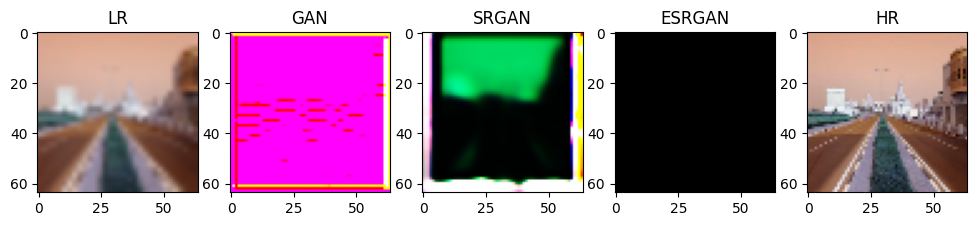

In [12]:
# =========================
# 9. VISUAL RESULTS
# =========================
idx = np.random.randint(0, len(hr_images))

lr = lr_images[idx]
hr = hr_images[idx]

gan_out = gen.predict(lr[np.newaxis,...])[0]
sr_out = gen_sr.predict(lr[np.newaxis,...])[0]
esr_out = gen_esr.predict(lr[np.newaxis,...])[0]

plt.figure(figsize=(12,4))

plt.subplot(1,5,1); plt.imshow(lr); plt.title("LR")
plt.subplot(1,5,2); plt.imshow(gan_out); plt.title("GAN")
plt.subplot(1,5,3); plt.imshow(sr_out); plt.title("SRGAN")
plt.subplot(1,5,4); plt.imshow(esr_out); plt.title("ESRGAN")
plt.subplot(1,5,5); plt.imshow(hr); plt.title("HR")

plt.show()